In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score

In [9]:
df = pd.read_csv('Dataset-Boston-2019.csv')
df = df[['Age', 'Result_sec', 'Gender']]
df = df.dropna()
df['Gender'] = df['Gender'].map({'M': 1, 'F': 0})
print(f"Dataset: {df.shape}")

Dataset: (26651, 3)


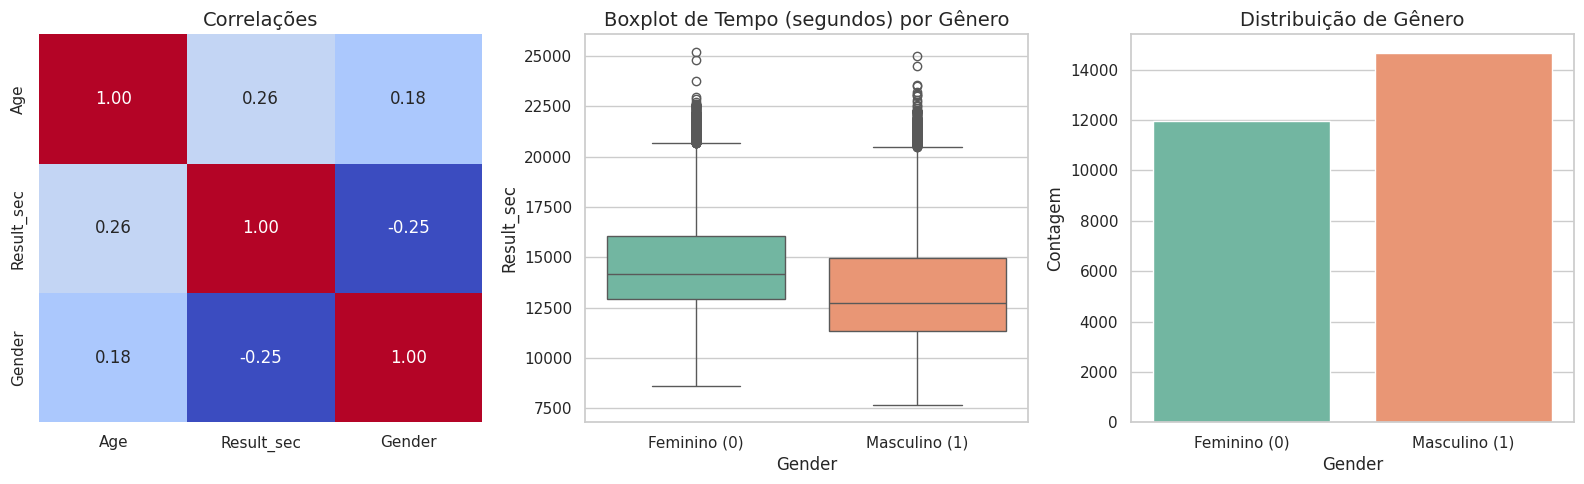

In [10]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(16, 5))

plt.subplot(1, 3, 1)
corr = df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", cbar=False)
plt.title('Correlações', fontsize=14)

plt.subplot(1, 3, 2)
sns.boxplot(x='Gender', y='Result_sec', data=df, hue='Gender', palette='Set2', legend=False)
plt.title('Boxplot de Tempo (segundos) por Gênero', fontsize=14)
plt.xticks(ticks=[0, 1], labels=['Feminino (0)', 'Masculino (1)'])

plt.subplot(1, 3, 3)
sns.countplot(x='Gender', data=df, hue='Gender', palette='Set2', legend=False)
plt.title('Distribuição de Gênero', fontsize=14)
plt.xticks(ticks=[0, 1], labels=['Feminino (0)', 'Masculino (1)'])
plt.ylabel('Contagem')

plt.tight_layout()
plt.show()

In [11]:
# COM OUTLIERS
X = df[['Age', 'Result_sec']]
y = df['Gender']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, stratify=y, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# SEM OUTLIERS
Q1 = df[['Age', 'Result_sec']].quantile(0.25)
Q3 = df[['Age', 'Result_sec']].quantile(0.75)
IQR = Q3 - Q1
df_clean = df[~((df[['Age', 'Result_sec']] < (Q1 - 1.5 * IQR)) | (df[['Age', 'Result_sec']] > (Q3 + 1.5 * IQR))).any(axis=1)]

X_clean = df_clean[['Age', 'Result_sec']]
y_clean = df_clean['Gender']
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_clean, y_clean, test_size=0.30, stratify=y_clean, random_state=42)

scaler_clean = StandardScaler()
X_train_scaled_c = scaler_clean.fit_transform(X_train_c)
X_test_scaled_c = scaler_clean.transform(X_test_c)

print(f"Dataset COM outliers: {df.shape[0]} amostras")
print(f"Dataset SEM outliers: {df_clean.shape[0]} amostras")
print(f"{(df.shape[0] - df_clean.shape[0])} registros removidos")

Dataset COM outliers: 26651 amostras
Dataset SEM outliers: 26131 amostras
520 registros removidos


In [12]:
print("REGRESSÃO LOGÍSTICA")

# Treinamento COM Outliers
rl = LogisticRegression(max_iter=5000, random_state=42)
rl.fit(X_train_scaled, y_train)
acc_com = accuracy_score(y_test, rl.predict(X_test_scaled))

# Treinamento SEM Outliers
rl_clean = LogisticRegression(max_iter=5000, random_state=42)
rl_clean.fit(X_train_scaled_c, y_train_c)
y_pred_c = rl_clean.predict(X_test_scaled_c)
acc_sem = accuracy_score(y_test_c, y_pred_c)

print(f"Acurácia COM Outliers: {acc_com:.4f}")
print(f"Acurácia SEM Outliers: {acc_sem:.4f}")
print("")

print("Detalhamento - Sem Outliers")
cm = confusion_matrix(y_test_c, y_pred_c)
tn, fp, fn, tp = cm.ravel()
print(classification_report(y_test_c, y_pred_c))
print(f"Sensibilidade (Taxa de acerto para 'M'): {tp / (tp + fn):.4f}")
print(f"Especificidade (Taxa de acerto para 'F'): {tn / (tn + fp):.4f}")

REGRESSÃO LOGÍSTICA
Acurácia COM Outliers: 0.6598
Acurácia SEM Outliers: 0.6619

Detalhamento - Sem Outliers
              precision    recall  f1-score   support

           0       0.66      0.50      0.57      3508
           1       0.66      0.79      0.72      4332

    accuracy                           0.66      7840
   macro avg       0.66      0.65      0.65      7840
weighted avg       0.66      0.66      0.65      7840

Sensibilidade (Taxa de acerto para 'M'): 0.7895
Especificidade (Taxa de acerto para 'F'): 0.5043


In [17]:
print("KNN")

KValores = [3, 5, 7, 9, 11, 15, 21]
KMelhor = 0
KnnMelhorAcuracia = 0

for k in KValores:
    knn_otimizado = KNeighborsClassifier(n_neighbors=k)
    knn_otimizado.fit(X_train_scaled_c, y_train_c)
    acc = knn_otimizado.score(X_test_scaled_c, y_test_c)
    print(f"K={k} para acurácia: {acc:.4f}")

    if acc > KnnMelhorAcuracia:
        KnnMelhorAcuracia = acc
        KMelhor = k

print("")
print(f"Melhor K encontrado: {KMelhor}")
print("")

knn = KNeighborsClassifier(n_neighbors=KMelhor)
knn.fit(X_train_scaled, y_train)
acc_com = accuracy_score(y_test, knn.predict(X_test_scaled))

knn_clean = KNeighborsClassifier(n_neighbors=KMelhor)
knn_clean.fit(X_train_scaled_c, y_train_c)
y_pred_c = knn_clean.predict(X_test_scaled_c)
acc_sem = accuracy_score(y_test_c, y_pred_c)

print(f"Acurácia COM Outliers: (K={KMelhor}): {acc_com:.4f}")
print(f"Acurácia SEM Outliers: (K={KMelhor}): {acc_sem:.4f}\n")

print("Detalhamento - Sem Outliers")
cm = confusion_matrix(y_test_c, y_pred_c)
tn, fp, fn, tp = cm.ravel()
print(classification_report(y_test_c, y_pred_c))
print(f"Sensibilidade (Taxa de acerto para 'M'): {tp / (tp + fn):.4f}")
print(f"Especificidade (Taxa de acerto para 'F'): {tn / (tn + fp):.4f}")

KNN
K=3 para acurácia: 0.6727
K=5 para acurácia: 0.6810
K=7 para acurácia: 0.6921
K=9 para acurácia: 0.7013
K=11 para acurácia: 0.7073
K=15 para acurácia: 0.7103
K=21 para acurácia: 0.7207

Melhor K encontrado: 21

Acurácia COM Outliers: (K=21): 0.7169
Acurácia SEM Outliers: (K=21): 0.7207

Detalhamento - Sem Outliers
              precision    recall  f1-score   support

           0       0.67      0.74      0.70      3508
           1       0.77      0.71      0.74      4332

    accuracy                           0.72      7840
   macro avg       0.72      0.72      0.72      7840
weighted avg       0.72      0.72      0.72      7840

Sensibilidade (Taxa de acerto para 'M'): 0.7087
Especificidade (Taxa de acerto para 'F'): 0.7355


In [14]:
print("MLP")

TamanhoRedeCamadas = [(10, 10), (50, 50), (100,), (100, 50)]
MelhorRede = None
mlpMelhorAcuracia = 0

print("- Otimizando a configuração da Rede (base sem outliers) -")
for Camadas in TamanhoRedeCamadas:
    mlp_otimizacao = MLPClassifier(hidden_layer_sizes=Camadas, max_iter=2000, random_state=42)
    mlp_otimizacao.fit(X_train_scaled_c, y_train_c)
    acc = mlp_otimizacao.score(X_test_scaled_c, y_test_c)
    print(f"Camadas={Camadas} para Acurácia: {acc:.4f}")

    if acc > mlpMelhorAcuracia:
        mlpMelhorAcuracia = acc
        MelhorRede = Camadas

print(f"\nMelhor configuração MLP encontrada: {MelhorRede}\n")

# Avaliando com e sem Outliers
mlp = MLPClassifier(hidden_layer_sizes=MelhorRede, max_iter=2000, random_state=42)
mlp.fit(X_train_scaled, y_train)
acc_com = accuracy_score(y_test, mlp.predict(X_test_scaled))

mlp_clean = MLPClassifier(hidden_layer_sizes=MelhorRede, max_iter=2000, random_state=42)
mlp_clean.fit(X_train_scaled_c, y_train_c)
y_pred_c = mlp_clean.predict(X_test_scaled_c)
acc_sem = accuracy_score(y_test_c, y_pred_c)

print(f"Acurácia COM Outliers (Camadas={MelhorRede}): {acc_com:.4f}")
print(f"Acurácia SEM Outliers (Camadas={MelhorRede}): {acc_sem:.4f}\n")

# Detalhamento (Base Sem Outliers)
print("- Detalhamento do cenário Sem Outliers -")
cm = confusion_matrix(y_test_c, y_pred_c)
tn, fp, fn, tp = cm.ravel()
print(classification_report(y_test_c, y_pred_c))
print(f"Sensibilidade (Taxa de acerto para 'M'): {tp / (tp + fn):.4f}")
print(f"Especificidade (Taxa de acerto para 'F'): {tn / (tn + fp):.4f}")

MLP
- Otimizando a configuração da Rede (base sem outliers) -
Camadas=(10, 10) para Acurácia: 0.7297
Camadas=(50, 50) para Acurácia: 0.7258
Camadas=(100,) para Acurácia: 0.7300
Camadas=(100, 50) para Acurácia: 0.7286

Melhor configuração MLP encontrada: (100,)

Acurácia COM Outliers (Camadas=(100,)): 0.7350
Acurácia SEM Outliers (Camadas=(100,)): 0.7300

- Detalhamento do cenário Sem Outliers -
              precision    recall  f1-score   support

           0       0.67      0.78      0.72      3508
           1       0.79      0.69      0.74      4332

    accuracy                           0.73      7840
   macro avg       0.73      0.73      0.73      7840
weighted avg       0.74      0.73      0.73      7840

Sensibilidade (Taxa de acerto para 'M'): 0.6921
Especificidade (Taxa de acerto para 'F'): 0.7768


In [15]:
print("=" * 40)
print("NAIVE BAYES")
print("=" * 40)

# Treinamento COM Outliers
nb = GaussianNB()
nb.fit(X_train_scaled, y_train)
acc_com = accuracy_score(y_test, nb.predict(X_test_scaled))

# Treinamento SEM Outliers
nb_clean = GaussianNB()
nb_clean.fit(X_train_scaled_c, y_train_c)
y_pred_c = nb_clean.predict(X_test_scaled_c)
acc_sem = accuracy_score(y_test_c, y_pred_c)

print(f"Acurácia COM Outliers: {acc_com:.4f}")
print(f"Acurácia SEM Outliers: {acc_sem:.4f}\n")

# Detalhamento (Base Sem Outliers)
print("- Detalhamento do cenário Sem Outliers -")
cm = confusion_matrix(y_test_c, y_pred_c)
tn, fp, fn, tp = cm.ravel()
print(classification_report(y_test_c, y_pred_c))
print(f"Sensibilidade (Taxa de acerto para 'M'): {tp / (tp + fn):.4f}")
print(f"Especificidade (Taxa de acerto para 'F'): {tn / (tn + fp):.4f}")

NAIVE BAYES
Acurácia COM Outliers: 0.6592
Acurácia SEM Outliers: 0.6653

- Detalhamento do cenário Sem Outliers -
              precision    recall  f1-score   support

           0       0.68      0.48      0.56      3508
           1       0.66      0.81      0.73      4332

    accuracy                           0.67      7840
   macro avg       0.67      0.65      0.65      7840
weighted avg       0.67      0.67      0.65      7840

Sensibilidade (Taxa de acerto para 'M'): 0.8135
Especificidade (Taxa de acerto para 'F'): 0.4823


In [16]:
# ==============================================================================
# CÉLULA 6: Tabela Comparativa e Exportação do Melhor Modelo
# ==============================================================================
import pandas as pd
import joblib
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix
from IPython.display import display

# Agrupando os modelos otimizados (treinados sem outliers) que estão na memória
modelos = {
    'Regressão Logística': rl_clean,
    'Naive Bayes': nb_clean,
    'KNN (K=21)': knn_clean,
    'MLP (Camadas=(100,))': mlp_clean
}

resultados_finais = []

print("Gerando métricas comparativas...\n")

# Calculando todas as métricas para a base Limpa (Sem Outliers)
for nome, modelo in modelos.items():
    # Realizando predições
    y_pred = modelo.predict(X_test_scaled_c)

    # Extraindo métricas
    acc = accuracy_score(y_test_c, y_pred)
    prec = precision_score(y_test_c, y_pred)
    sens = recall_score(y_test_c, y_pred) # Sensibilidade

    # Calculando a especificidade manualmente pela matriz
    cm = confusion_matrix(y_test_c, y_pred)
    tn, fp, fn, tp = cm.ravel()
    espec = tn / (tn + fp)

    resultados_finais.append({
        'Modelo': nome,
        'Acurácia': acc,
        'Precisão': prec,
        'Sensibilidade (Recall)': sens,
        'Especificidade': espec
    })

# ==============================================================================
# 1. EXIBINDO A TABELA COMPARATIVA
# ==============================================================================
print("=" * 65)
print("TABELA COMPARATIVA DE DESEMPENHO (CENÁRIO SEM OUTLIERS)")
print("=" * 65)

# Transformando a lista em um DataFrame para visualização mais limpa
df_resultados = pd.DataFrame(resultados_finais).set_index('Modelo')
# Ordenando pela Acurácia (do maior para o menor)
df_resultados = df_resultados.sort_values(by='Acurácia', ascending=False)

display(df_resultados.round(4))

# ==============================================================================
# 2. EXPORTAÇÃO DO MELHOR MODELO (MLP) E DO SCALER
# ==============================================================================
# Exportando o MLP limpo e o scaler limpo usado para normalizar os dados dele
arquivo_modelo = 'melhor_modelo_boston.pkl'
arquivo_scaler = 'scaler_boston.pkl'

joblib.dump(mlp_clean, arquivo_modelo)
joblib.dump(scaler_clean, arquivo_scaler)

print(f"Melhor modelo (MLP) exportado com sucesso: '{arquivo_modelo}'")
print(f"Scaler exportado com sucesso: '{arquivo_scaler}'")

Gerando métricas comparativas...

TABELA COMPARATIVA DE DESEMPENHO (CENÁRIO SEM OUTLIERS)


,Acurácia,Precisão,Sensibilidade (Recall),Especificidade
Modelo,,,,
"MLP (Camadas=(100,))",0.7300,0.7929,0.6921,0.7768
KNN (K=21),0.7207,0.7679,0.7087,0.7355
Naive Bayes,0.6653,0.6599,0.8135,0.4823
Regressão Logística,0.6619,0.6629,0.7895,0.5043


Melhor modelo (MLP) exportado com sucesso: 'melhor_modelo_boston.pkl'
Scaler exportado com sucesso: 'scaler_boston.pkl'
